# Reading the assumption report

Every mfgQC analysis checks its own assumptions and reports the outcome. It
warns, it quantifies the impact, and it recommends a next step, but it never
silently switches methods or transforms your data. This notebook walks the
anatomy of an assumption line, the difference between a p-value and an effect
size, and the two legitimate ways to respond when an assumption fails. Every cell
runs, so open it in Colab and try it on your own numbers.

<div class="nb-buttons"><a class="nb-btn" target="_blank" href="https://colab.research.google.com/github/cjbrant/mfgQC/blob/main/docs/guide/assumption-report.ipynb">Run in Colab</a><a class="nb-btn" target="_blank" href="https://github.com/cjbrant/mfgQC/blob/main/docs/guide/assumption-report.ipynb">View on GitHub</a><a class="nb-btn" target="_blank" href="https://raw.githubusercontent.com/cjbrant/mfgQC/main/docs/guide/assumption-report.ipynb" download>Download notebook</a></div>

Install it first (skip this if mfgQC is already in your environment):

In [ ]:
!pip install mfgqc

## The guardrail: report, never silently switch

This is the "statistical guardrails" pillar. If a capability study finds your
measurements are non-normal, it tells you and keeps computing the normal-theory
number you asked for. It does not quietly Box-Cox the data and hand you a
different Cpk. Auto-correction is opt-in only: a non-normal method runs only
when you pass `method=` explicitly.

The principle is to report, not decide. Each check
reports a binary verdict from the direct test of the assumption, plus two pieces
of adjacent context: practical impact and the test's resolving power at your
sample size. The context never flips the verdict, and the verdict never changes
the analysis. You decide what to do.

## Where the report comes from

Every result carries a list of structured `AssumptionCheck` records and renders
them in `.report()` under an Assumption checks block, followed by
Recommendations. Here is a small bore-diameter study of 15 parts. Print the
report and read the last line.

In [2]:
import numpy as np, pandas as pd, mfgqc

rng = np.random.default_rng(11)
df = pd.DataFrame({"bore": np.round(rng.normal(10.0, 0.05, size=15), 4)})
qc = mfgqc.load(df, measure="bore").spec(lower=9.8, upper=10.2)
print(qc.capability())

Process Capability (method=normal)
n = 15   mean = 10.008
sigma (within)  =   n/a
sigma (overall) = 0.044324
Cp/Cpk sigma    = overall

Cp  = 1.504  95% CI (0.954, 2.05)
Cpk = 1.446  95% CI (0.884, 2.01)   (Cpu=1.446, Cpl=1.562)
Pp  = 1.504    Ppk = 1.446   (Ppu=1.446, Ppl=1.562)
Cpm =   n/a

Assumption checks:
  [PASS] normality (Anderson-Darling): AD=0.368, p=0.383; est. Cpk impact 3.4%; n=15 [low power]


The same data is available structurally via `.to_dict()`. Consume that from
code; never parse the report text. Each record is one `AssumptionCheck`.

In [3]:
qc.capability().to_dict()["assumptions"]

[{'name': 'normality',
  'test': 'Anderson-Darling',
  'statistic': 0.36791797495857104,
  'p_value': 0.3825213544886901,
  'passed': True,
  'magnitude': 0.033915625974104434,
  'magnitude_label': 'est. Cpk impact',
  'reliability': 'low_power',
  'n': 15,
  'recommendation': None}]

## Anatomy of an assumption line

Take that PASS line apart, field by field. Each piece maps to a field on the
`AssumptionCheck` dataclass (`mfgqc/assumptions.py`):

```text
[PASS] normality (Anderson-Darling): AD=0.368, p=0.383; est. Cpk impact 3.4%; n=15 [low power]
  │        │            │              │       │              │                   │     │
  │        │            │              │       │              │                   │     └─ reliability
  │        │            │              │       │              │                   └─ n (sample size)
  │        │            │              │       │              └─ magnitude + magnitude_label
  │        │            │              │       └─ p_value
  │        │            │              └─ statistic
  │        │            └─ test
  │        └─ name
  └─ passed (verdict)
```

| Part of the line | `AssumptionCheck` field | What it means |
| --- | --- | --- |
| `[PASS]` / `[FAIL]` | `passed` | The binary verdict from the direct test at $\alpha = 0.05$. Nothing else in the line changes this. |
| `normality` | `name` | What was checked. |
| `(Anderson-Darling)` | `test` | The exact test used to reach the verdict. |
| `AD=0.368` | `statistic` | The test statistic. |
| `p=0.383` | `p_value` | P-value of the direct test. `passed` is simply `p >= 0.05`. Omitted when a test has no defined p-value. |
| `est. Cpk impact 3.4%` | `magnitude` + `magnitude_label` | The practical-impact / effect-size context: here, how much the capability index would move under a non-normal fit. |
| `n=15` | `n` | The sample size the check ran on. |
| `[low power]` | `reliability` | The test's resolving power at this $n$: `ok` (no marker), `low power`, or `oversensitive`. |

The `magnitude_label` varies by check: `est. Cpk impact` and `skew` for
normality, `variance ratio` for homogeneity (Levene), `dispersion ratio` for
attribute charts, `lag-1 autocorr` for independence, `subgroup count`/`ndc` for
adequacy rules. The label tells you what the magnitude number is.

You can pull any field straight off the record. No text parsing.

In [4]:
chk = qc.capability().to_dict()["assumptions"][0]
print("name:        ", chk["name"])
print("test:        ", chk["test"])
print("statistic:   ", round(chk["statistic"], 3))
print("p_value:     ", round(chk["p_value"], 3))
print("passed:      ", chk["passed"])
print("magnitude:   ", round(chk["magnitude"], 3), f"({chk['magnitude_label']})")
print("reliability: ", chk["reliability"])
print("n:           ", chk["n"])

name:         normality
test:         Anderson-Darling
statistic:    0.368
p_value:      0.383
passed:       True
magnitude:    0.034 (est. Cpk impact)
reliability:  low_power
n:            15


## `[PASS]` vs `[FAIL]`: a verdict, not an action

A `[FAIL]` means the assumption was rejected at $\alpha = 0.05$. It does not
mean mfgQC changed anything. The number above the assumption block was still
computed with the method you asked for. A FAIL is a flag that says "the reported
number rests on an assumption that didn't hold; read on, and decide." The
recommendation line tells you the conventional remedy; acting on it is your
call.

The marker is driven purely by the direct test of the assumption, never by the
context fields. This is deliberate: it stops a coincidentally-small impact
estimate from issuing a false all-clear on grossly non-normal data. The verdict
answers "did the assumption hold?"; the context answers "does it matter, and
could the test even tell?"

### `[low power]` and `[oversensitive]`: the reliability flag

The reliability flag is a fact about the test, not a judgment about your data:

- `[low power]`: the sample is small enough ($n < 20$ for normality, with
  per-check thresholds) that the test has weak power to detect a real
  violation. A `[PASS]` carrying `[low power]` is weak evidence: the test did
  not reject, but at this $n$ it might not have caught a violation that is
  genuinely there. Treat it as "no evidence against," not "confirmed."
- `[oversensitive]`: at very large $n$ ($> 5000$) significance tests reject
  trivial, practically-irrelevant departures. A `[FAIL]` carrying
  `[oversensitive]` is the cue to lean on the magnitude, not the p-value.

The bore study above carried `[low power]` because $n = 15$. That is why mfgQC
reports the effect size alongside the p-value: at small $n$ the p-value alone is
not enough to act on.

## Magnitude: statistical vs practical significance

A statistically significant violation can be practically negligible, and a
practically serious one can hide under a non-significant p-value at small $n$.
The p-value answers "is the departure real?"; the magnitude answers "is it big
enough to care about?" mfgQC reports both so you can judge practical
significance yourself.

In the PASS example above, `est. Cpk impact 3.4%` says: even if you switched to a
non-normal method, your Cpk would move by about 3%, not enough to change a
sourcing decision. The failing case below carries the same label, but it reads
89.1%. Same statistic name, completely different engineering consequence, and you
can only see the difference because the magnitude is on the line.

## A FAIL, worked end to end

Here is a genuinely right-skewed positive measurement, the kind you get from
flatness, surface roughness, or runout, where values are bounded at zero and
tail to the right. Build it with a gamma draw, run the default capability study,
and read the assumption block.

In [5]:
rng = np.random.default_rng(42)
x = np.round(rng.gamma(shape=2.0, scale=0.4, size=120) + 0.2, 3)
flat = pd.DataFrame({"flatness": x})
qc_flat = mfgqc.load(flat, measure="flatness").spec(upper=3.0)

print(qc_flat.capability())                    # default: method='normal'

Process Capability (method=normal)
n = 120   mean = 0.94012
sigma (within)  =   n/a
sigma (overall) = 0.5121
Cp/Cpk sigma    = overall

Cp  =   n/a
Cpk = 1.341  95% CI (1.16, 1.52)   (Cpu=1.341, Cpl=  n/a)
Pp  =   n/a    Ppk = 1.341   (Ppu=1.341, Ppl=  n/a)
Cpm =   n/a

Assumption checks:
  [FAIL] normality (Anderson-Darling): AD=2.74, p=6.14e-07; est. Cpk impact 89.1%; n=120

Recommendations:
  - Data are not normal (AD=2.74, p=6.14e-07); for capability use a non-normal method (method='clements'/'johnson').


Read the FAIL line: the Anderson-Darling test rejects normality hard
(`p=6.14e-07`), and the magnitude says it matters (`est. Cpk impact 89.1%`). The
default normal method reports `Cpk = 1.341`, comfortably above the usual 1.33
gate. The recommendation names the conventional remedy. mfgQC did not act on it;
it reported it.

The chart shows why. Plot the result and look at the right tail against the
fitted normal curve.

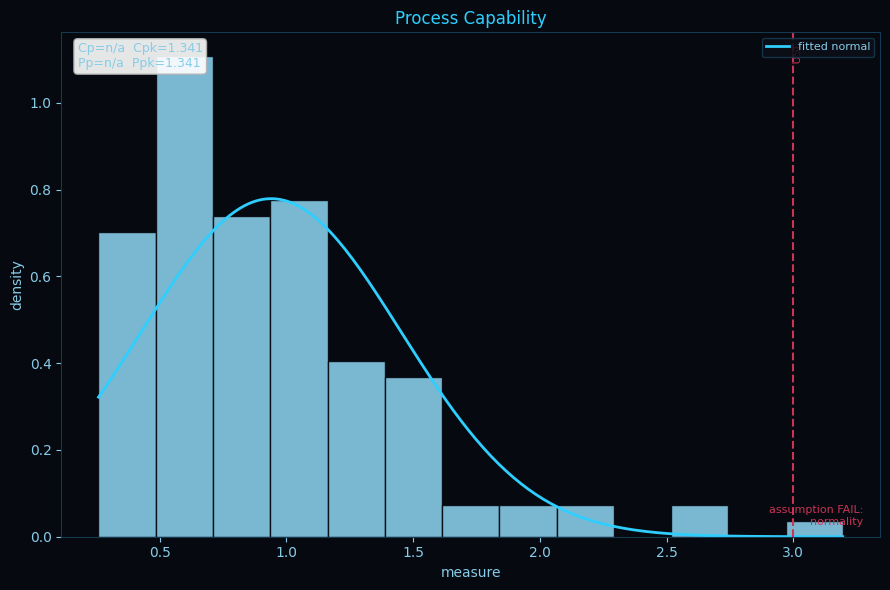

In [6]:
qc_flat.capability().view()

Now opt into Box-Cox explicitly and compare the number. This is the only way a
non-normal method runs: you pass `method=` on purpose.

In [7]:
print(qc_flat.capability(method="boxcox"))     # explicit opt-in

Process Capability (method=boxcox)
n = 120   mean = 0.94012
sigma (within)  =   n/a
sigma (overall) = 0.5121
Cp/Cpk sigma    = box-cox (lambda=0.017)

Cp  =   n/a  CI: n/a (non-normal method)
Cpk = 0.8366  CI: n/a (non-normal method)   (Cpu=0.8366, Cpl=  n/a)
Pp  =   n/a    Ppk = 0.8366   (Ppu=0.8366, Ppl=  n/a)
Cpm =   n/a

Assumption checks:
  [FAIL] normality (Anderson-Darling): AD=2.74, p=6.14e-07; est. Cpk impact 89.1%; n=120

Recommendations:
  - Data are not normal (AD=2.74, p=6.14e-07); for capability use a non-normal method (method='clements'/'johnson').


The default normal method reported `Cpk = 1.341`. The Box-Cox number is
`Cpk = 0.8366`. The normality assumption was inflating capability by a third.
That is the reason mfgQC refuses to transform silently: had it auto-applied
Box-Cox, you would never have seen 1.341 and might never have questioned it; had
it auto-suppressed the transform, you would have reported a 1.341 that overstates the process by a third.

The default never transforms. Non-normal methods (`boxcox`, `clements`,
`johnson`) run only when you pass `method=` explicitly. `qc.capability()` with
no argument always reports the normal-theory number, FAIL flag and all. The
choice to transform is yours, on the record, in the provenance history.

## When to opt into a correction, and when not to

A FAIL gives you two legitimate responses. Picking the right one is an
engineering judgment, not a statistical one.

**DO choose a non-normal method when the shape is the true nature of the data.**
If the measurement is inherently skewed or bounded (flatness, roundness, taper,
particle counts, time-to-event), then normality was never the right model and
the non-normal index is the one that fits the data. The flatness example above is exactly
this case: opt into `method="boxcox"` (or `"clements"`/`"johnson"`), and the
choice is recorded in the lineage.

**DON'T "correct away" a FAIL that is signaling a special cause.** A normality
FAIL can also mean your process is not in control: a mixture of two streams, a
drifting mean, a tool-change step, an outlier from a bad part. That is a special
cause to investigate, not a distribution to transform. Box-Cox-ing an unstable
process to make it look capable is precisely what mfgQC refuses to do silently;
do not do it by hand either. Before reaching for a transform, plot the data on a
control chart and confirm the process is stable.

The discipline: establish stability first, then assess capability. A capability
index, normal or non-normal, only means something for an in-control process. To
make the distinction concrete, here is a second non-normal-looking dataset that
is really two streams stacked together: a tool that drifted to a new setpoint
partway through the run. Its histogram fails normality for a reason that a
transform would only hide.

In [8]:
rng = np.random.default_rng(7)
stream_a = rng.normal(10.00, 0.05, size=60)   # before the tool change
stream_b = rng.normal(10.18, 0.05, size=60)   # after the tool change
mixed = np.round(np.concatenate([stream_a, stream_b]), 4)
mix = pd.DataFrame({"bore": mixed, "order": np.arange(1, 121)})
qc_mix = mfgqc.load(mix, measure="bore").spec(lower=9.8, upper=10.4)

print(qc_mix.capability())

Process Capability (method=normal)
n = 120   mean = 10.083
sigma (within)  =   n/a
sigma (overall) = 0.10302
Cp/Cpk sigma    = overall

Cp  = 0.9707  95% CI (0.847, 1.09)
Cpk = 0.9147  95% CI (0.784, 1.05)   (Cpu=1.027, Cpl=0.9147)
Pp  = 0.9707    Ppk = 0.9147   (Ppu=1.027, Ppl=0.9147)
Cpm =   n/a

Assumption checks:
  [FAIL] normality (Anderson-Darling): AD=3.3, p=2.62e-08; est. Cpk impact 0.4%; n=120

Recommendations:
  - Data are not normal (AD=3.3, p=2.62e-08); for capability use a non-normal method (method='clements'/'johnson').


The capability report flags non-normality again, but the cause here is a step
change, not an inherently skewed measurement. The way to see it is an
individuals control chart in run order. Plot one, and read the assumption block
and the out-of-control signals.

In [9]:
print(qc_mix.control_chart(kind="i_mr"))

Control Chart: i_mr (specified); rules=nelson
Individual: CL=10.083  UCL=10.221  LCL=9.9439
MR: CL=0.052171  UCL=0.17044  LCL=0

Out-of-control signals: 104
  point 4 (location): nelson_5 - two of three points beyond 2 sigma (same side)
  point 5 (location): nelson_5 - two of three points beyond 2 sigma (same side)
  point 6 (location): nelson_5 - two of three points beyond 2 sigma (same side)
  point 7 (location): nelson_6 - four of five points beyond 1 sigma (same side)
  point 9 (location): nelson_2 - nine points in a row on one side of CL
  point 10 (location): nelson_2 - nine points in a row on one side of CL
  point 11 (location): nelson_2 - nine points in a row on one side of CL
  point 12 (location): nelson_2 - nine points in a row on one side of CL
  point 13 (location): nelson_2 - nine points in a row on one side of CL
  point 14 (location): nelson_2 - nine points in a row on one side of CL
  point 15 (location): nelson_2 - nine points in a row on one side of CL
  point 16 (l

The chart finds the special cause directly. The independence check fails (the
points are autocorrelated because the mean steps), and the run after the tool
change sits outside limits computed from the whole run. This is a process to
fix, not a distribution to transform. Here is the same chart drawn.

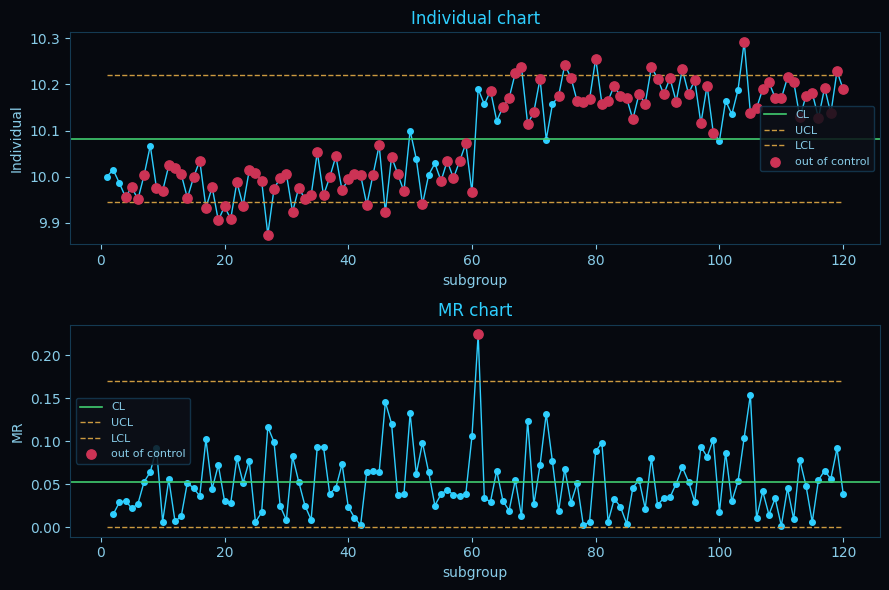

In [10]:
qc_mix.control_chart(kind="i_mr").view()

Read the two cases together. The flatness data is genuinely skewed: the right
response is to opt into a non-normal method on purpose. The mixed-stream data is
unstable: the right response is to find and fix the tool change, then reassess
capability on the stable process. Both fail a normality check in the capability
report, so the capability report alone cannot tell them apart. The control chart
is how you make the distinction, and the engineering judgment about which case
you are in is the one mfgQC leaves to you.

## Next

- [Quickstart](/guide/quickstart/) walks the `load → spec → analysis` flow and the result surface.
- [Non-normal capability](/reference/non-normal-capability/) covers choosing among Box-Cox, Clements, and Johnson.
- [Control charts](/reference/control-charts/) establish stability before judging capability.
- The [Reference](/reference/) gives the formula, assumptions, and source standard behind every method.